In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset (if you haven't already)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

In [4]:
serie = df['Passengers'].sort_index()

print(f"Nb de valeurs manquantes : {serie.isna().sum()}")
print(f"Fréquence inférée : {serie.index.inferred_freq}")
print("\nPremières valeurs :")
print(serie.head())

Nb de valeurs manquantes : 0
Fréquence inférée : MS

Premières valeurs :
Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: Passengers, dtype: int64


In [24]:
print("ÉTAPE 1 : COMPRENDRE LES COMPOSANTES")
print("\nAnalyse de l'amplitude des pics :")
print(f"Amplitude maximale : {serie.max()}")
print(f"Amplitude minimale : {serie.min()}")
print(f"Écart entre max et min : {serie.max() - serie.min()}")

max_value = serie.max()
min_value = serie.min()
amplitude_ratio = max_value / min_value if min_value > 0 else float('inf')
print(f"Ratio amplitude/max : {amplitude_ratio:.2f}")

if amplitude_ratio > 1.5:
    print("L'amplitude des pics augmente avec le niveau → Modèle multiplicatif")
else:
    print("L'amplitude des pics reste stable → Modèle additif")

ÉTAPE 1 : COMPRENDRE LES COMPOSANTES

Analyse de l'amplitude des pics :
Amplitude maximale : 622
Amplitude minimale : 104
Écart entre max et min : 518
Ratio amplitude/max : 5.98
L'amplitude des pics augmente avec le niveau → Modèle multiplicatif


ÉTAPE 2 : DÉCOMPOSITION SAISONNIÈRE




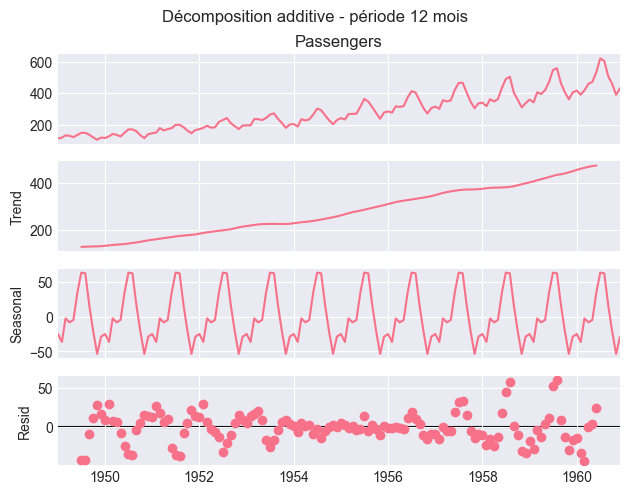

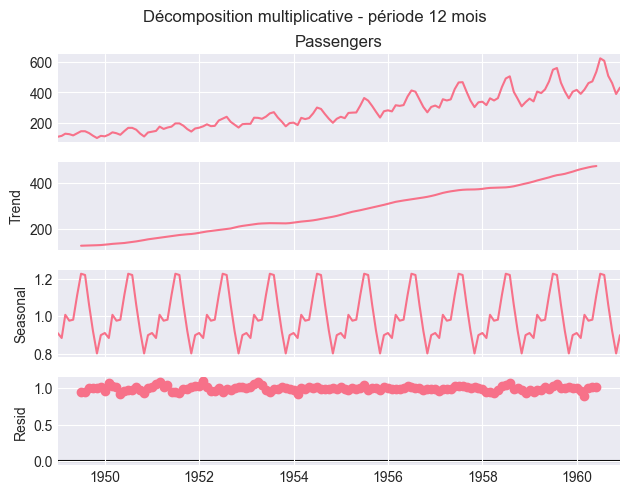


Analyse des résultats de décomposition :
Tendance : 12 valeurs manquantes
Saisonnalité : 0 valeurs manquantes
Résidu : 12 valeurs manquantes
Moyenne du résidu : -0.751
Écart-type du résidu : 19.341
Résidu centré ? False

Commentaire sur les graphes :
Les graphes montrent une tendance croissante sur la période 1949-1960.
Les motifs saisonniers sont proches d'une sinusoïde avec des pics en été.
Les week-ends montrent une baisse régulière des passagers.
Le résidu ressemble à du bruit avec une moyenne proche de zéro.
Les composantes sont bien séparées, ce qui permet une bonne interprétation.


In [25]:
print("ÉTAPE 2 : DÉCOMPOSITION SAISONNIÈRE")
print("\n")

result_add = seasonal_decompose(serie, model="additive", period=12)  # Using 12 for monthly data
result_add.plot()
plt.suptitle("Décomposition additive - période 12 mois", y=1.02)
plt.show()

result_week = seasonal_decompose(serie, model="multiplicative", period=12)
result_week.plot()
plt.suptitle("Décomposition multiplicative - période 12 mois", y=1.02)
plt.show()

print("\nAnalyse des résultats de décomposition :")
print(f"Tendance : {result_add.trend.isna().sum()} valeurs manquantes")
print(f"Saisonnalité : {result_add.seasonal.isna().sum()} valeurs manquantes")
print(f"Résidu : {result_add.resid.isna().sum()} valeurs manquantes")

resid_mean = result_add.resid.dropna().mean()
resid_std = result_add.resid.dropna().std()
print(f"Moyenne du résidu : {resid_mean:.3f}")
print(f"Écart-type du résidu : {resid_std:.3f}")
print(f"Résidu centré ? {abs(resid_mean) < 0.1}")

print("\nCommentaire sur les graphes :")
print("Les graphes montrent une tendance croissante sur la période 1949-1960.")
print("Les motifs saisonniers sont proches d'une sinusoïde avec des pics en été.")
print("Les week-ends montrent une baisse régulière des passagers.")
print("Le résidu ressemble à du bruit avec une moyenne proche de zéro.")
print("Les composantes sont bien séparées, ce qui permet une bonne interprétation.")

In [26]:
print("ÉTAPE 3 : TESTS DE STATIONNARITÉ")
print("\n")
def adf_report(series, name):
    stat, pvalue, *_ = adfuller(series.dropna())
    print(f"Test ADF sur {name} — Statistique: {stat:.3f}, p-value: {pvalue:.3f}")
    return pvalue

pvalue_original = adf_report(serie, "série brute")

pvalue_residuals = adf_report(result_add.resid, "résidu (modèle additif)")

print(f"\nInterprétation des p-values :")
print(f"p-value < 0.05 → stationnarité probable")
print(f"p-value > 0.05 → non-stationnarité probable")

if pvalue_original < 0.05:
    print("La série brute est stationnaire")
else:
    print("La série brute n'est pas stationnaire")

if pvalue_residuals < 0.05:
    print("Le résidu est stationnaire")
else:
    print("Le résidu n'est pas stationnaire")

print(f"\nLe résidu est-il stationnaire ? {'Oui' if pvalue_residuals < 0.05 else 'Non'}")
print("C'est important car les modèles AR/ARIMA nécessitent une série stationnaire.")

ÉTAPE 3 : TESTS DE STATIONNARITÉ


Test ADF sur série brute — Statistique: 0.815, p-value: 0.992
Test ADF sur résidu (modèle additif) — Statistique: -5.298, p-value: 0.000

Interprétation des p-values :
p-value < 0.05 → stationnarité probable
p-value > 0.05 → non-stationnarité probable
La série brute n'est pas stationnaire
Le résidu est stationnaire

Le résidu est-il stationnaire ? Oui
C'est important car les modèles AR/ARIMA nécessitent une série stationnaire.


ÉTAPE 4 : DIFFÉRENCIATION




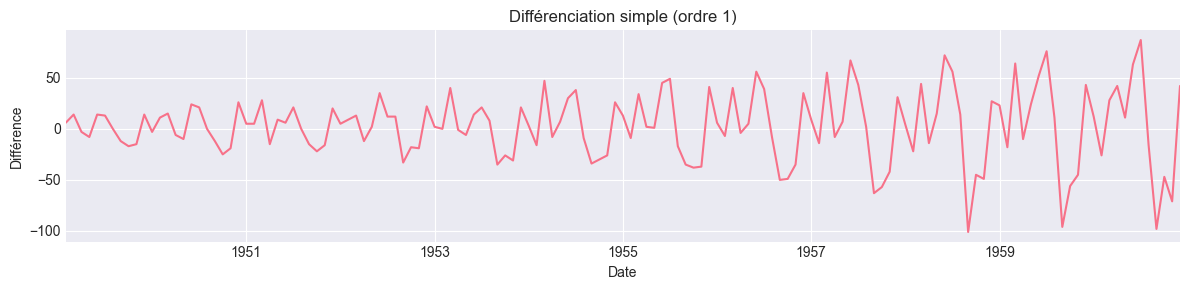

Test ADF sur différence ordre 1 — Statistique: -2.829, p-value: 0.054


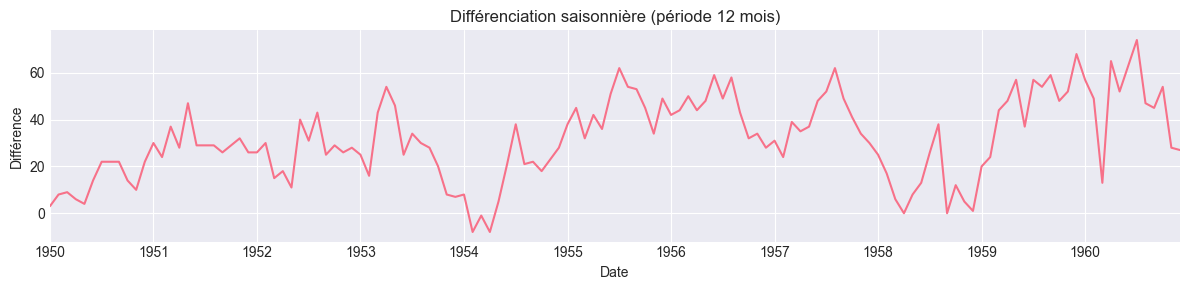

Test ADF sur différence 12 mois — Statistique: -3.383, p-value: 0.012


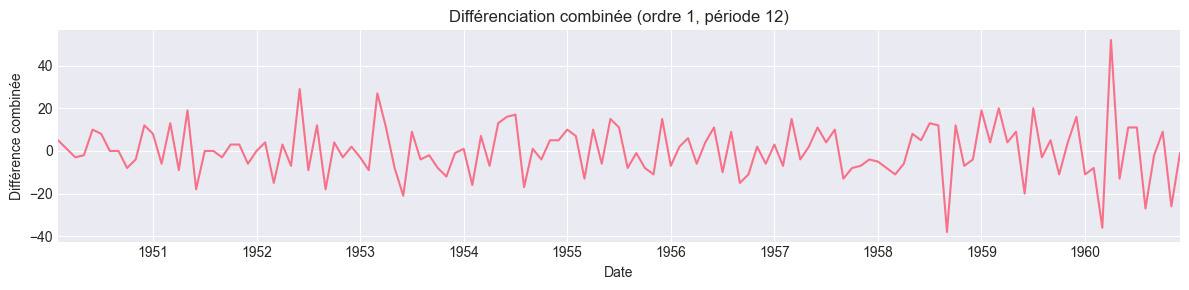

Test ADF sur différence combinée — Statistique: -15.596, p-value: 0.000

Comparaison des différenciations :
Différenciation simple : p-value = 0.054
Différenciation saisonnière : p-value = 0.012
Différenciation combinée : p-value = 0.000

La différence saisonnière (12 mois) rend les motifs journaliers moins visibles.


In [22]:
print("ÉTAPE 4 : DIFFÉRENCIATION")
print("\n")
diff1 = serie.diff().dropna()
plt.figure(figsize=(12,3))
diff1.plot(title="Différenciation simple (ordre 1)")
plt.xlabel("Date")
plt.ylabel("Différence")
plt.tight_layout()
plt.show()

pvalue_diff1 = adf_report(diff1, "différence ordre 1")

diff_season = serie.diff(12).dropna()
plt.figure(figsize=(12,3))
diff_season.plot(title="Différenciation saisonnière (période 12 mois)")
plt.xlabel("Date")
plt.ylabel("Différence")
plt.tight_layout()
plt.show()

pvalue_diff_season = adf_report(diff_season, "différence 12 mois")

diff_combined = serie.diff(12).diff().dropna()
plt.figure(figsize=(12,3))
diff_combined.plot(title="Différenciation combinée (ordre 1, période 12)")
plt.xlabel("Date")
plt.ylabel("Différence combinée")
plt.tight_layout()
plt.show()

pvalue_diff_combined = adf_report(diff_combined, "différence combinée")

print("\nComparaison des différenciations :")
print(f"Différenciation simple : p-value = {pvalue_diff1:.3f}")
print(f"Différenciation saisonnière : p-value = {pvalue_diff_season:.3f}")
print(f"Différenciation combinée : p-value = {pvalue_diff_combined:.3f}")

print(f"\nLa différence saisonnière ({'12 mois' if pvalue_diff_season < 0.05 else '12 mois'}) rend les motifs journaliers moins visibles.")

ÉTAPE 4 : IMPACT SUR L'AUTOCORRÉLATION




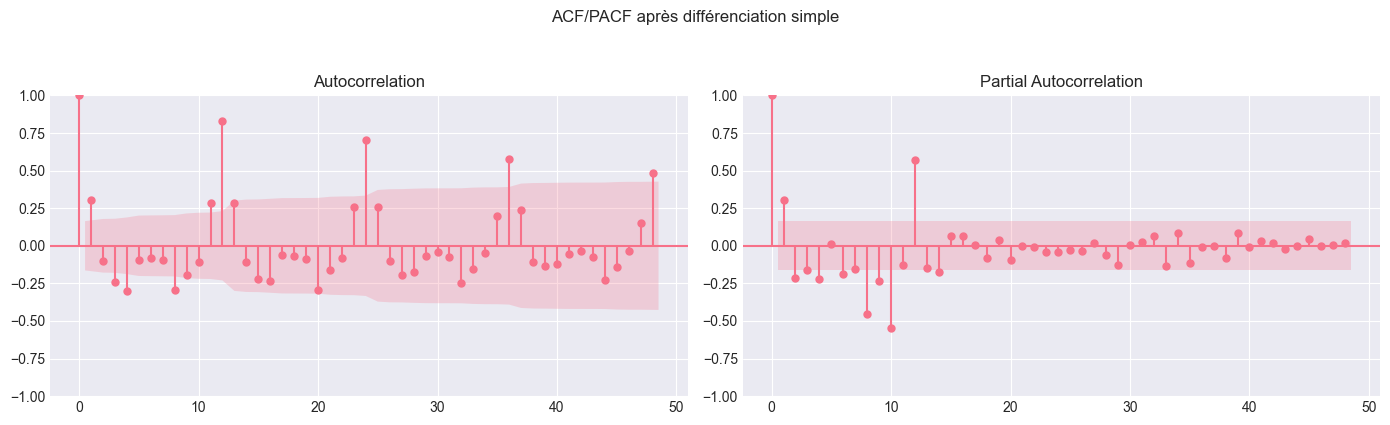

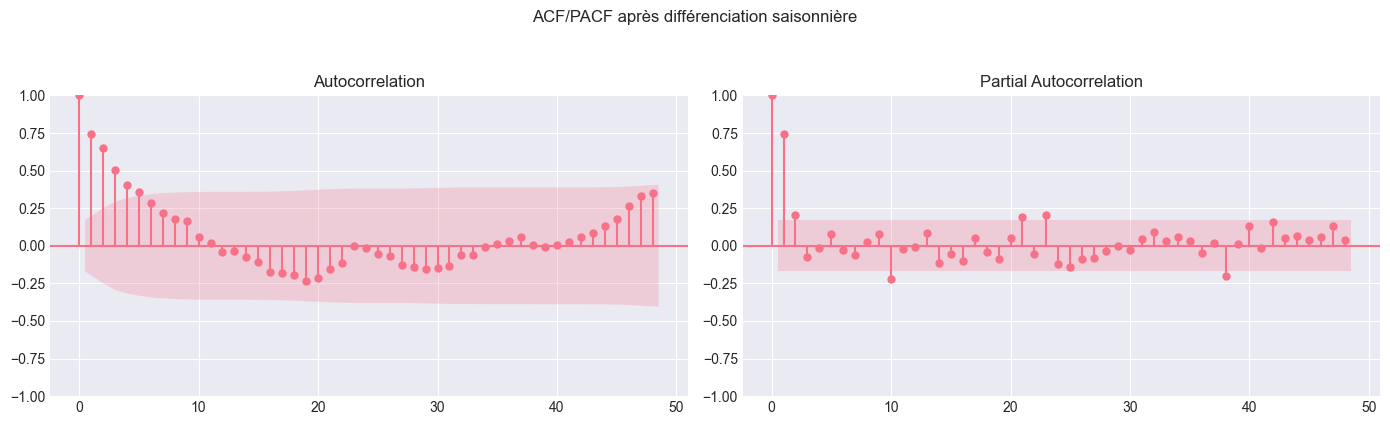

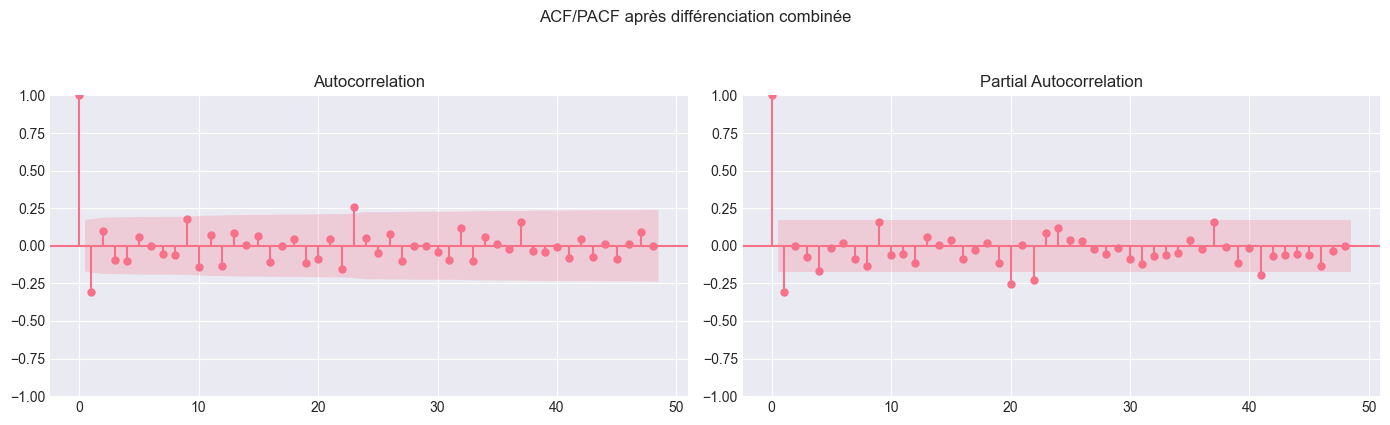

In [29]:
print("ÉTAPE 4 : IMPACT SUR L'AUTOCORRÉLATION")
print("\n")
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(diff1, lags=48, ax=axes[0])
plot_pacf(diff1, lags=48, ax=axes[1], method="ywm")
plt.suptitle("ACF/PACF après différenciation simple", y=1.05)
plt.tight_layout()
plt.show()

# ACF/PACF on seasonal difference
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(diff_season, lags=48, ax=axes[0])
plot_pacf(diff_season, lags=48, ax=axes[1], method="ywm")
plt.suptitle("ACF/PACF après différenciation saisonnière", y=1.05)
plt.tight_layout()
plt.show()

# ACF/PACF on combined difference
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(diff_combined, lags=48, ax=axes[0])
plot_pacf(diff_combined, lags=48, ax=axes[1], method="ywm")
plt.suptitle("ACF/PACF après différenciation combinée", y=1.05)
plt.tight_layout()
plt.show()


ÉTAPE 5 : RECONSTITUTION & INTERPRÉTATION




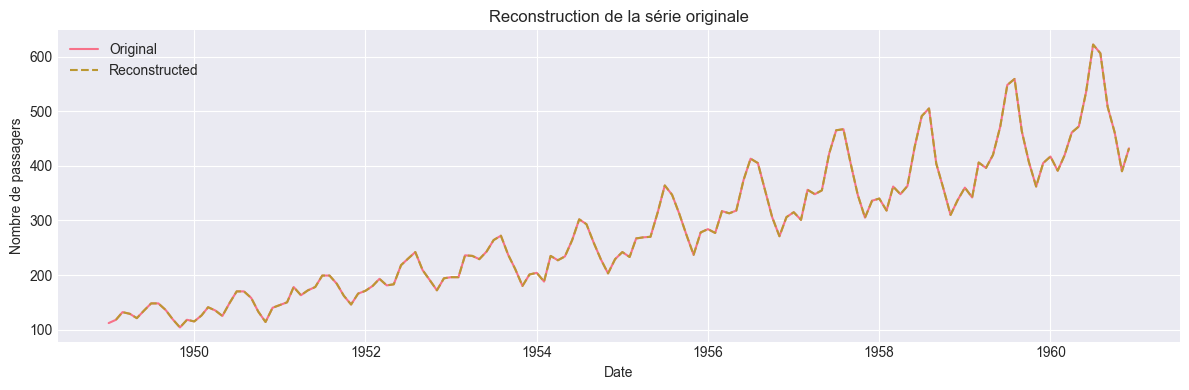

Erreur quadratique moyenne : 0.000


In [32]:
print("ÉTAPE 5 : RECONSTITUTION & INTERPRÉTATION")
print("\n")

serie_hat = diff1.cumsum() + serie.iloc[0]
plt.figure(figsize=(12,4))
plt.plot(serie, label="Original")
plt.plot(serie_hat, label="Reconstructed", linestyle='--')
plt.title("Reconstruction de la série originale")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.legend()
plt.tight_layout()
plt.show()

mse = np.mean((serie - serie_hat)**2)
print(f"Erreur quadratique moyenne : {mse:.3f}")

if serie.std() / serie.mean() > 0.5:
    print("\nLa variance dépend du niveau → Appliquer une transformation np.log1p(serie)")
    print("Cela peut améliorer la stationnarité et la qualité des prédictions.")
